In [4]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset de Glucosa
df_glucosa = pd.read_csv('glucosa_data.csv')

print("=== FASE DE LIMPIEZA Y PREPARACIÓN: GLUCOSA ===")
print(f"Total de registros iniciales: {len(df_glucosa)}")

# 2. Verificar nulos y duplicados
nulos_g = df_glucosa.isnull().sum().sum()
duplicados_g = df_glucosa.duplicated().sum()
print(f"Valores nulos: {nulos_g}")
print(f"Registros duplicados: {duplicados_g}")

# 3. Auditoría y Exclusión de Outliers por IQR
print("\nAuditoría y Filtrado de Outliers:")
cols_g = ['Edad', 'IMC', 'Actividad_Fisica', 'Nivel_Glucosa']
mask_g = pd.Series(True, index=df_glucosa.index)

for col in cols_g:
    Q1 = df_glucosa[col].quantile(0.25)
    Q3 = df_glucosa[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers_cnt = ((df_glucosa[col] < lim_inf) | (df_glucosa[col] > lim_sup)).sum()
    print(f"   - Variable '{col}': {outliers_cnt} atípicos fuera de [{lim_inf:.2f}, {lim_sup:.2f}]")
    mask_g &= (df_glucosa[col] >= lim_inf) & (df_glucosa[col] <= lim_sup)

# Aplicar exclusión formal
df_glucosa = df_glucosa[mask_g].reset_index(drop=True)
print(f"\n¡Dataset de glucosa depurado! Registros finales limpios: {len(df_glucosa)}")

=== FASE DE LIMPIEZA Y PREPARACIÓN: GLUCOSA ===
Total de registros iniciales: 2000
Valores nulos: 0
Registros duplicados: 0

Auditoría y Filtrado de Outliers:
   - Variable 'Edad': 0 atípicos fuera de [-11.00, 109.00]
   - Variable 'IMC': 16 atípicos fuera de [14.23, 35.86]
   - Variable 'Actividad_Fisica': 0 atípicos fuera de [-5.50, 14.50]
   - Variable 'Nivel_Glucosa': 3 atípicos fuera de [58.86, 219.42]

¡Dataset de glucosa depurado! Registros finales limpios: 1981


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Separar variables
X_g = df_glucosa[['Edad', 'IMC', 'Actividad_Fisica']]
y_g = df_glucosa['Nivel_Glucosa']

# 2. División train/test
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_g, y_g, test_size=0.2, random_state=42)

# 3. Entrenar modelo
modelo_glucosa = LinearRegression()
modelo_glucosa.fit(X_train_g, y_train_g)

# 4. Métricas
y_pred_g = modelo_glucosa.predict(X_test_g)
mse_g = mean_squared_error(y_test_g, y_pred_g)
r2_g = r2_score(y_test_g, y_pred_g)

print("--- RESULTADOS DEL MODELO DE GLUCOSA (DATOS LIMPIOS) ---")
print(f"Intercepto (b0): {modelo_glucosa.intercept_:.4f}")
for col, coef in zip(X_g.columns, modelo_glucosa.coef_):
    print(f"Coeficiente para {col}: {coef:.4f}")
print(f"MSE: {mse_g:.4f}")
print(f"R²: {r2_g:.4f}")

--- RESULTADOS DEL MODELO DE GLUCOSA (DATOS LIMPIOS) ---
Intercepto (b0): 66.1448
Coeficiente para Edad: 1.2256
Coeficiente para IMC: 0.9135
Coeficiente para Actividad_Fisica: -2.0097
MSE: 223.9043
R²: 0.6948


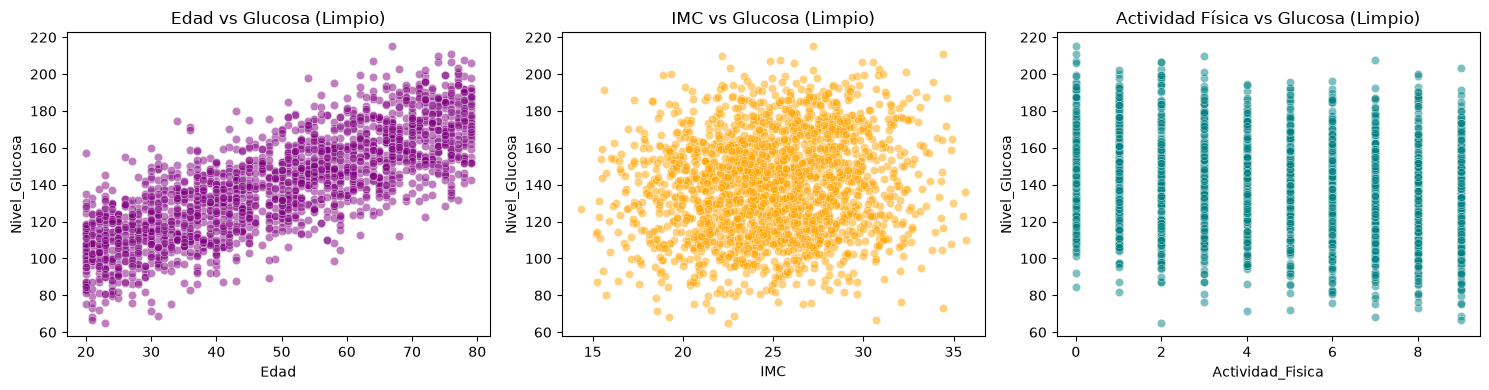

¡Modelo limpio exportado exitosamente como 'modelo_glucosa.pkl'!

--- PRUEBA DE CARGA Y PREDICCIÓN (GLUCOSA) ---
Datos ingresados -> Edad: 45, IMC: 24.5, Ejercicio: 4h
Glucosa predicha: 135.6397 mg/dL


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd

# 1. Gráficas
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x=df_glucosa['Edad'], y=df_glucosa['Nivel_Glucosa'], alpha=0.5, color='purple')
plt.title('Edad vs Glucosa (Limpio)')
plt.subplot(1, 3, 2)
sns.scatterplot(x=df_glucosa['IMC'], y=df_glucosa['Nivel_Glucosa'], alpha=0.5, color='orange')
plt.title('IMC vs Glucosa (Limpio)')
plt.subplot(1, 3, 3)
sns.scatterplot(x=df_glucosa['Actividad_Fisica'], y=df_glucosa['Nivel_Glucosa'], alpha=0.5, color='teal')
plt.title('Actividad Física vs Glucosa (Limpio)')
plt.tight_layout()
plt.show()

# 2. Exportar modelo
joblib.dump(modelo_glucosa, 'modelo_glucosa.pkl')
print("¡Modelo limpio exportado exitosamente como 'modelo_glucosa.pkl'!")

# 3. Prueba con DataFrame
modelo_g_cargado = joblib.load('modelo_glucosa.pkl')
datos_paciente = pd.DataFrame([[45, 24.5, 4]], columns=['Edad', 'IMC', 'Actividad_Fisica'])
pred_g = modelo_g_cargado.predict(datos_paciente)
print(f"\n--- PRUEBA DE CARGA Y PREDICCIÓN (GLUCOSA) ---")
print(f"Datos ingresados -> Edad: 45, IMC: 24.5, Ejercicio: 4h")
print(f"Glucosa predicha: {pred_g[0]:.4f} mg/dL")